# พลอตข้อมูลพายุยางิ
* ใช้เรดาร์ uf สถานีเชียงราย
* พลอต ppi แปลงเป็นกริด พลอตในพิกัดภูมิศาสตร์
* ปล.ไม่ได้มีการประมวลผลใด ๆ ด้าน quality control เพียงแต่ใช้ corrected_reflectivity

In [1]:
!pip install -q arm-pyart
!pip install -q rioxarray

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.4/14.4 MB 81.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 100.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.4/142.4 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 96.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 61.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.0/302.0 kB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 199.6/199.6 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.3/84.3 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.3/47.3 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.9/13.9 MB 89.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==202

Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
CRI240 RADAR PPI PROCESSING - dBZ AND RAINFALL RATE
RADAR FILE INSPECTION
File: CRI240@202409091000.uf.bz2
Size: 7.64 MB
Path: /content/drive/MyDrive/1shared_etc/0อบรมอาจารย์อังกูรเชียงราย/0radar_data/CRI240@202409091000.uf.bz2
Attempting to read: CRI240@202409091000.uf.bz2
⚠ Direct read failed: Invalid data stream...
Trying file rename strategies...
  Trying extension: .uf
✓ SUCCESS with extension: .uf

📡 RADAR SPECIFICATIONS:
  • Rays (azimuths): 986
  • Gates (range bins): 480
  • Sweeps (elevations): 2
  • Max range: 240.2 km
  • Location: 19.961471°N, 99.881593°E
  • Altitude: 444 m
  • Elevation angles: ['1.09°', '1.09°']
  • Scan time: 2024-09-09 10:00:02 UTC

🔍 AVAILABLE FIELDS:
   1. reflectivity
      └─ Reflectivity
      └─ Units: dBZ
   2. velocity
      └─ Mean dopper velocity
      └─ Units: meters_per_second
   3. spec

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

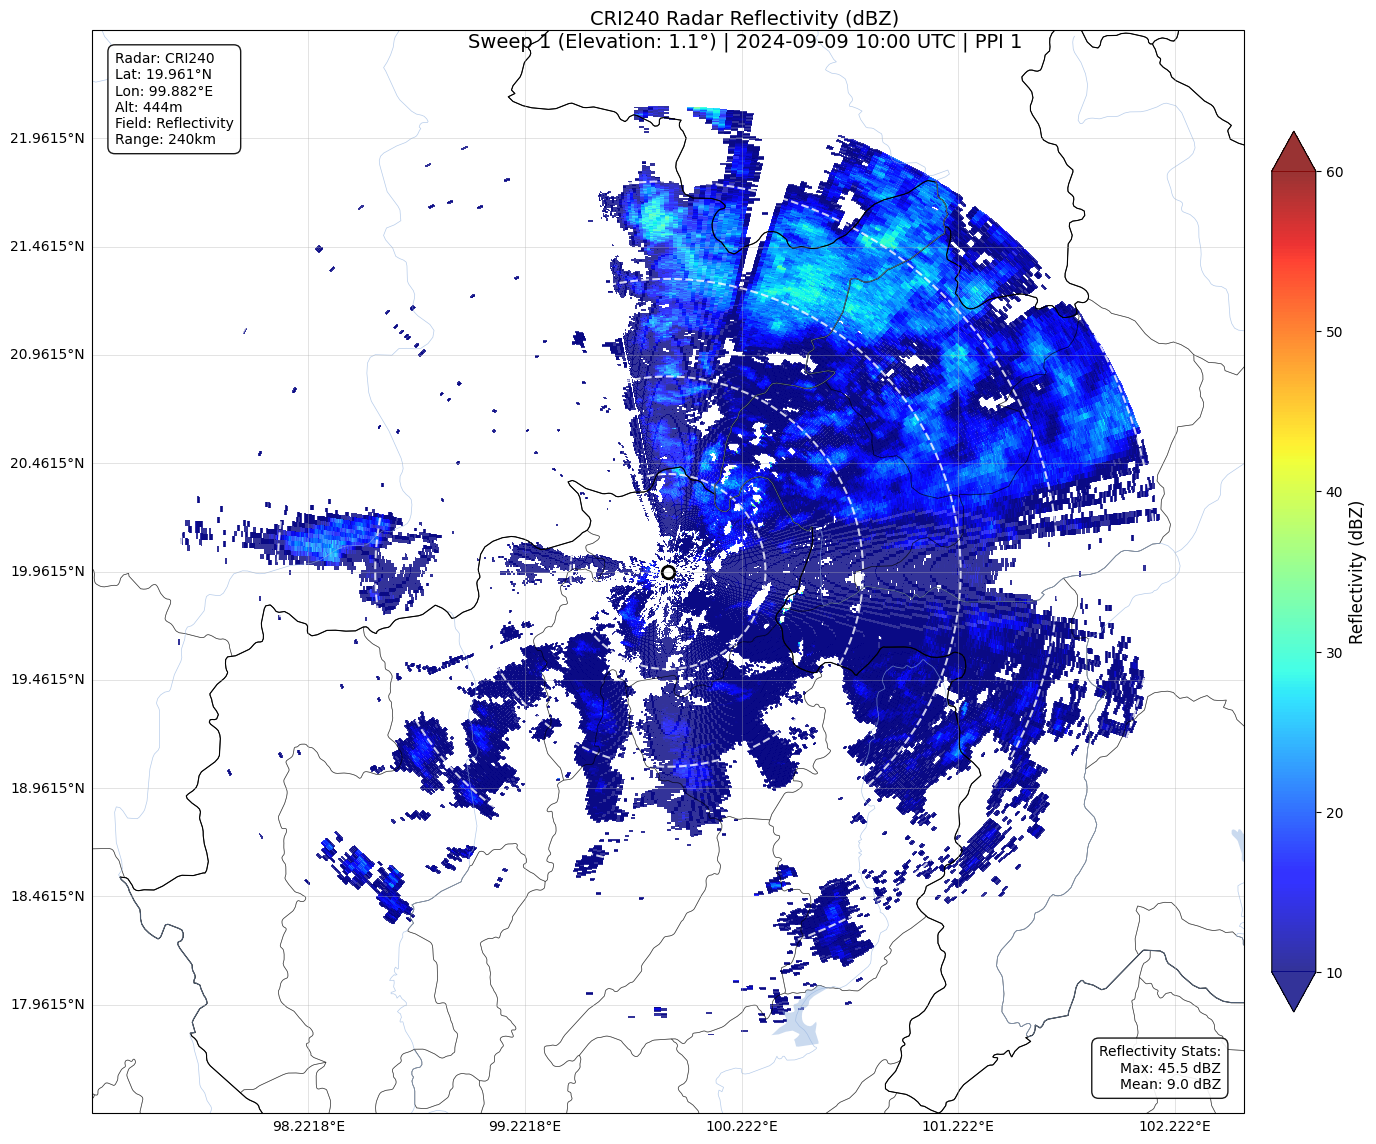

Plotting rainfall rate for sweep 1...
Creating PPI rainfall rate map for sweep 0...
Extracting PPI coordinates for sweep 0...
✓ PPI rainfall map saved: cri240_ppi_rainfall_sweep1.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

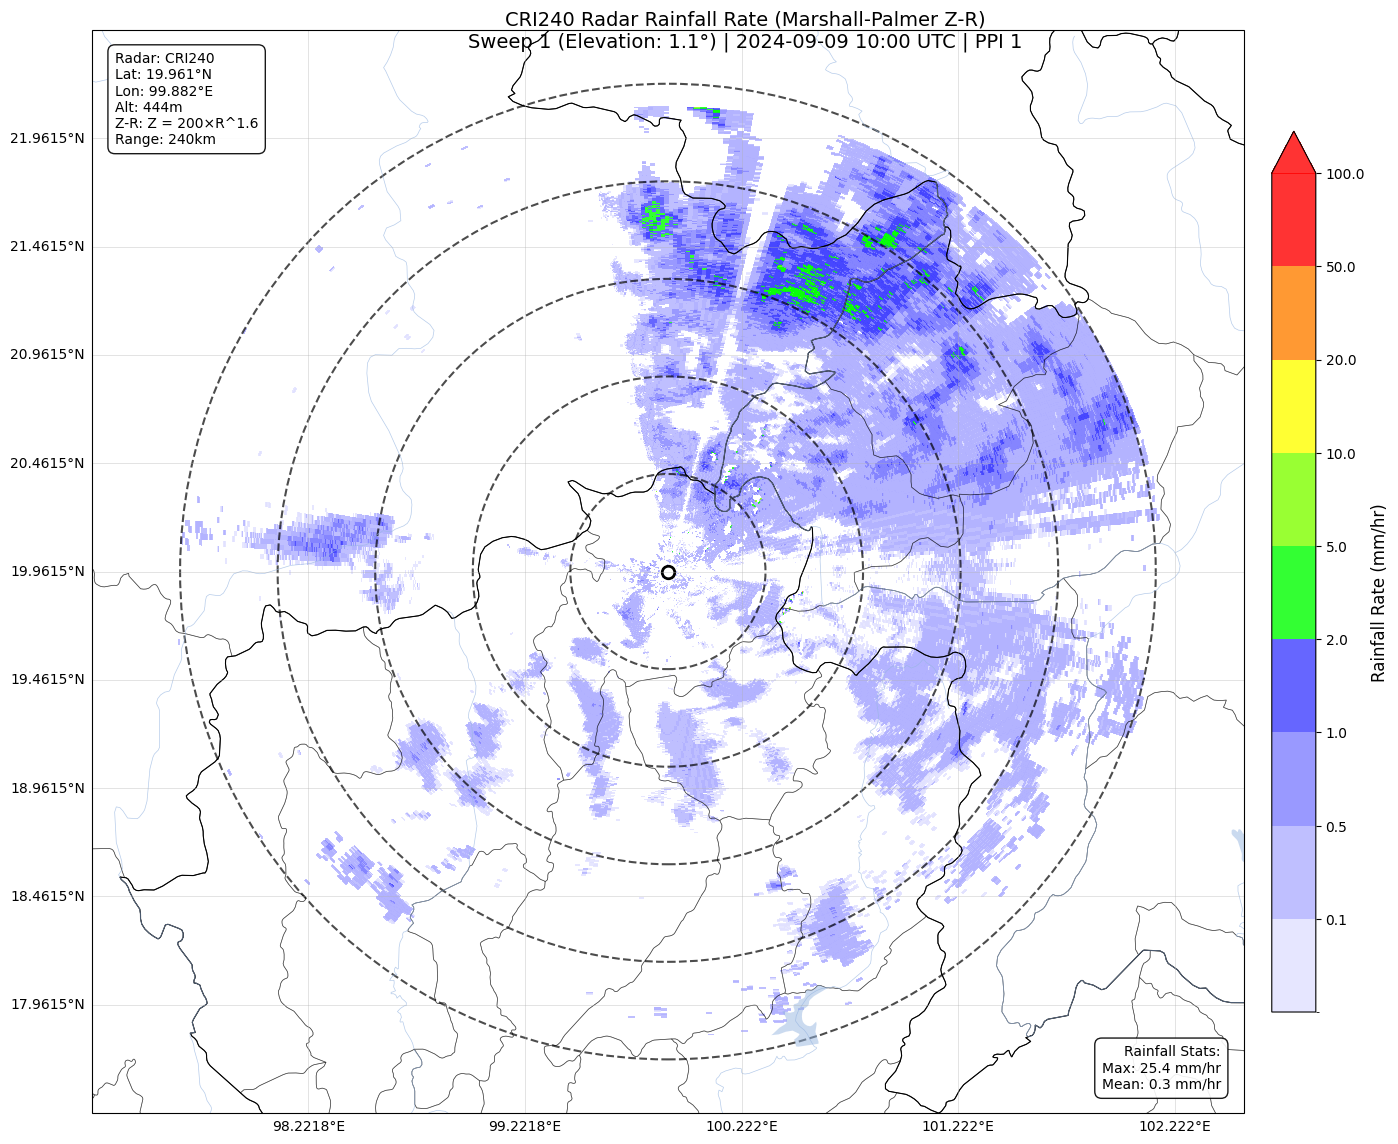

✓ Both products created successfully for sweep 1

--- SWEEP 2 ---
Plotting corrected_reflectivity for sweep 2...
Creating PPI reflectivity map for sweep 1...
Extracting PPI coordinates for sweep 1...
✓ PPI reflectivity map saved: cri240_ppi_reflectivity_sweep2.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

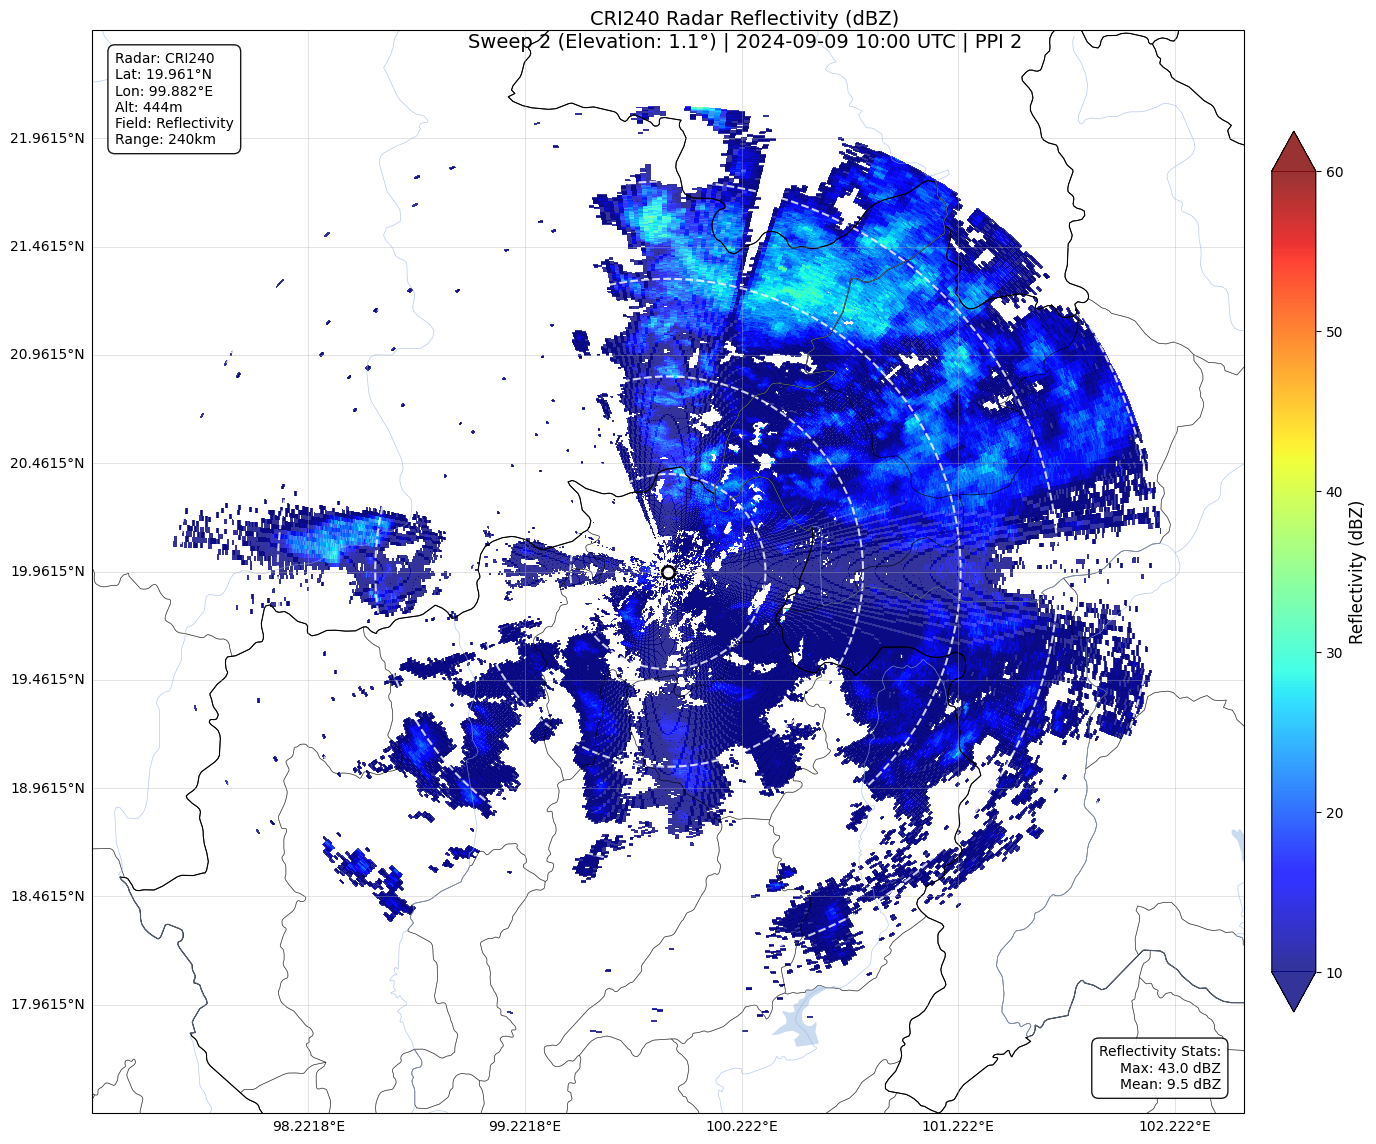

Plotting rainfall rate for sweep 2...
Creating PPI rainfall rate map for sweep 1...
Extracting PPI coordinates for sweep 1...
✓ PPI rainfall map saved: cri240_ppi_rainfall_sweep2.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

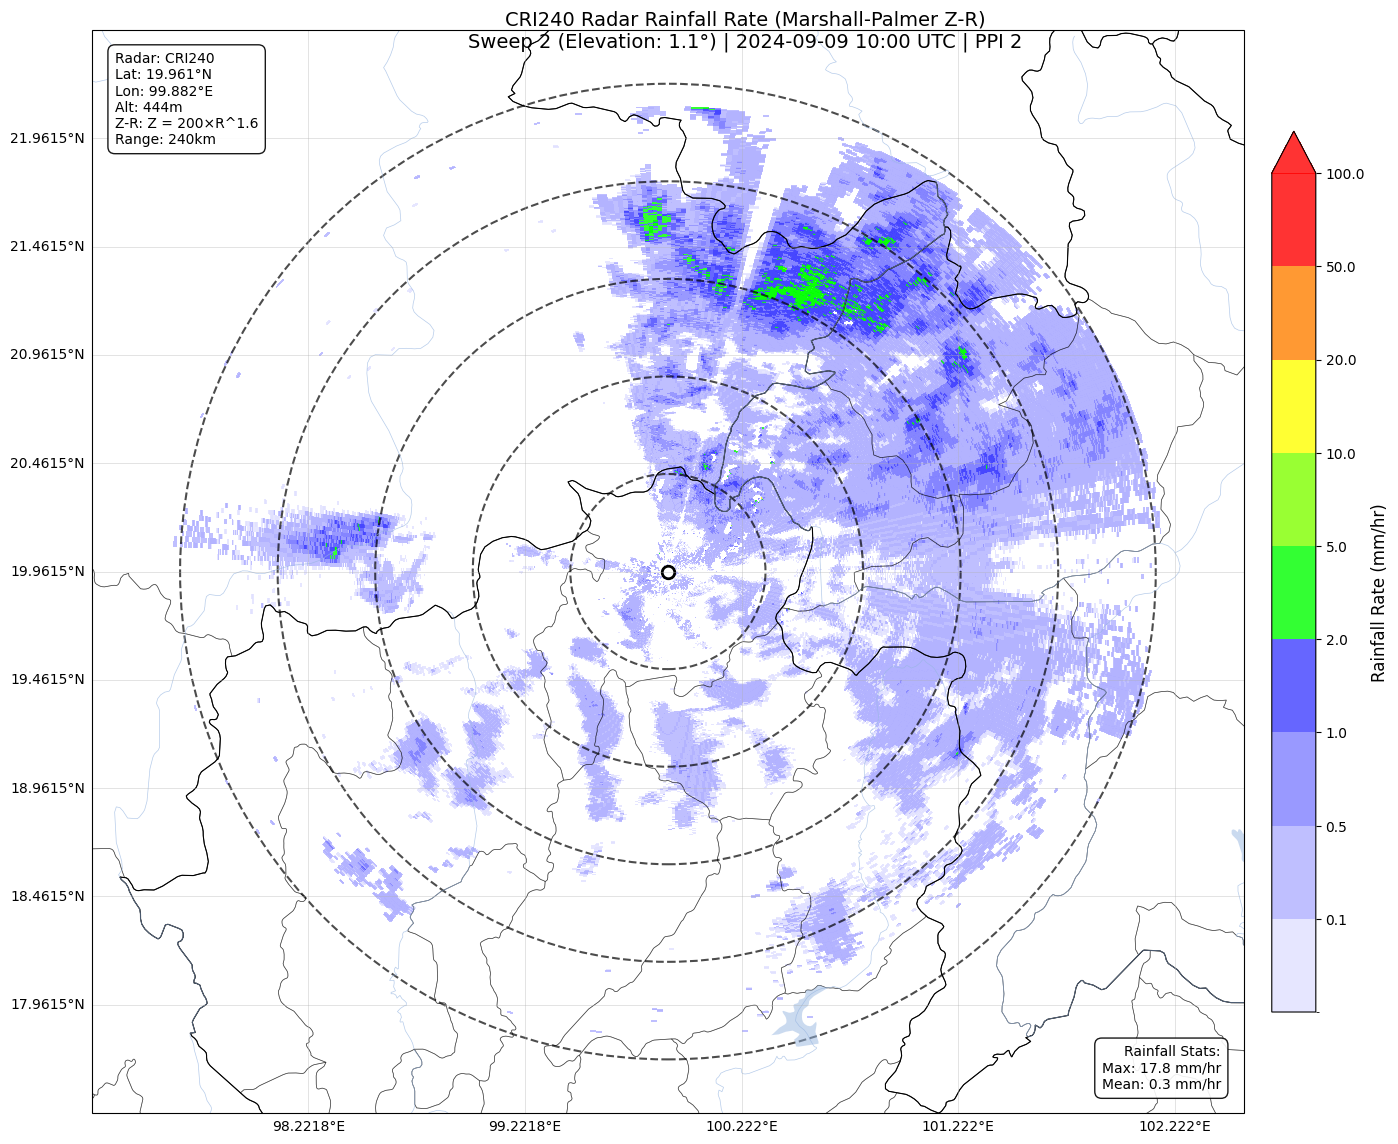

✓ Both products created successfully for sweep 2

📋 PROCESSING SUMMARY
Sweep 1: dBZ ✓ | Rainfall ✓
Sweep 2: dBZ ✓ | Rainfall ✓

🎉 ALL PROCESSING COMPLETED SUCCESSFULLY!
   ✓ 2 sweeps processed
   ✓ 4 plots created (2 dBZ + 2 rainfall)


In [6]:
# CRI Radar PPI Processor - dBZ and Rainfall Rate for Multiple Sweeps
# Adapted for Google Colab - Plots both reflectivity and rainfall rate for first two sweeps

import os
import tempfile
import shutil
import numpy as np
import pyart
import xarray as xr
from datetime import datetime
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import warnings
from scipy.ndimage import label
from google.colab import drive, files
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Install required packages if needed
try:
    import cartopy
except ImportError:
    !pip install cartopy

# Suppress warnings
warnings.filterwarnings("ignore", category=DeprecationWarning, module="pyart.map.gates_to_grid")
warnings.filterwarnings("ignore", category=RuntimeWarning, message="Mean of empty slice")

# Mount Google Drive
print("Mounting Google Drive...")
drive.mount('/content/drive')

def check_radar_file(file_path):
    """Check radar file properties and available fields"""
    print("="*60)
    print("RADAR FILE INSPECTION")
    print("="*60)

    if not os.path.exists(file_path):
        print(f"✗ File not found: {file_path}")
        return None

    print(f"File: {os.path.basename(file_path)}")
    print(f"Size: {os.path.getsize(file_path) / (1024*1024):.2f} MB")
    print(f"Path: {file_path}")

    # Try to read the file
    radar = try_read_radar_file(file_path)
    if radar is None:
        return None

    print("\n📡 RADAR SPECIFICATIONS:")
    print(f"  • Rays (azimuths): {radar.nrays}")
    print(f"  • Gates (range bins): {radar.ngates}")
    print(f"  • Sweeps (elevations): {radar.nsweeps}")
    print(f"  • Max range: {radar.range['data'][-1]/1000:.1f} km")

    # Radar location
    lat = radar.latitude['data'][0]
    lon = radar.longitude['data'][0]
    alt = radar.altitude['data'][0]
    print(f"  • Location: {lat:.6f}°N, {lon:.6f}°E")
    print(f"  • Altitude: {alt:.0f} m")

    # Elevation angles
    if radar.nsweeps > 1:
        elevations = [radar.elevation['data'][radar.sweep_start_ray_index['data'][i]] for i in range(radar.nsweeps)]
        print(f"  • Elevation angles: {[f'{el:.2f}°' for el in elevations]}")
    else:
        print(f"  • Elevation angle: {radar.elevation['data'][0]:.2f}°")

    # Time information
    try:
        scan_time = pyart.util.datetime_from_radar(radar)
        print(f"  • Scan time: {scan_time.strftime('%Y-%m-%d %H:%M:%S UTC')}")
    except Exception as e:
        print(f"  • Scan time: Not available ({str(e)[:30]}...)")

    print("\n🔍 AVAILABLE FIELDS:")
    for i, field in enumerate(radar.fields.keys(), 1):
        field_info = radar.fields[field]
        print(f"  {i:2d}. {field}")
        if 'long_name' in field_info:
            print(f"      └─ {field_info['long_name']}")
        if 'units' in field_info:
            print(f"      └─ Units: {field_info['units']}")

    print("="*60)
    return radar

def try_read_radar_file(file_path):
    """Robust radar file reader with automatic renaming"""
    print(f"Attempting to read: {os.path.basename(file_path)}")

    # Strategy 1: Try reading directly
    try:
        radar = pyart.io.read(file_path)
        print("✓ Direct read successful")
        return radar
    except Exception as e:
        print(f"⚠ Direct read failed: {str(e)[:60]}...")

    # Strategy 2: Try different extensions
    print("Trying file rename strategies...")

    extensions_to_try = ['.uf', '.UF', '.raw', '.vol', '']

    with tempfile.TemporaryDirectory() as temp_dir:
        original_name = os.path.basename(file_path)
        base_name = os.path.splitext(os.path.splitext(original_name)[0])[0]  # Remove all extensions

        for ext in extensions_to_try:
            try:
                temp_file_path = os.path.join(temp_dir, f"{base_name}{ext}")
                shutil.copy2(file_path, temp_file_path)

                print(f"  Trying extension: {ext if ext else '(no extension)'}")
                radar = pyart.io.read(temp_file_path)
                print(f"✓ SUCCESS with extension: {ext if ext else '(no extension)'}")
                return radar

            except Exception as e:
                continue

    # Strategy 3: Check if it's compressed
    try:
        import gzip
        with tempfile.NamedTemporaryFile(suffix='.uf') as temp_file:
            with gzip.open(file_path, 'rb') as gz_file:
                temp_file.write(gz_file.read())
                temp_file.flush()

            radar = pyart.io.read(temp_file.name)
            print("✓ SUCCESS! File was gzip compressed")
            return radar
    except Exception:
        pass

    print("✗ All reading strategies failed")
    return None

def calculate_rainfall_rate(reflectivity_dbz, a=200, b=1.6):
    """
    Calculate rainfall rate using Marshall-Palmer Z-R relationship
    Z = a * R^b, where Z is in mm^6/m^3 and R is in mm/hr

    Parameters:
    - reflectivity_dbz: Reflectivity in dBZ
    - a: Marshall-Palmer coefficient (default: 200)
    - b: Marshall-Palmer exponent (default: 1.6)

    Returns:
    - rainfall_rate: Rainfall rate in mm/hr
    """
    # Convert dBZ to linear Z (mm^6/m^3)
    z_linear = 10 ** (reflectivity_dbz / 10.0)

    # Apply Marshall-Palmer relationship: Z = a * R^b
    # Solve for R: R = (Z/a)^(1/b)
    rainfall_rate = (z_linear / a) ** (1.0 / b)

    # Set minimum threshold (avoid very small values)
    rainfall_rate = np.where(reflectivity_dbz < 5, 0, rainfall_rate)  # No rain below 5 dBZ

    return rainfall_rate

def get_ppi_coordinates(radar, sweep=0):
    """Extract PPI coordinates and data for geographic plotting"""
    print(f"Extracting PPI coordinates for sweep {sweep}...")

    # Get sweep information
    sweep_start = radar.sweep_start_ray_index['data'][sweep]
    sweep_end = radar.sweep_end_ray_index['data'][sweep]

    # Get radar location
    radar_lat = radar.latitude['data'][0]
    radar_lon = radar.longitude['data'][0]
    radar_alt = radar.altitude['data'][0]

    # Get range and azimuth data
    ranges = radar.range['data']  # in meters
    azimuths = radar.azimuth['data'][sweep_start:sweep_end+1]  # in degrees

    # Create coordinate meshes
    az_rad = np.radians(azimuths)
    range_mesh, az_mesh = np.meshgrid(ranges, az_rad)

    # Convert polar to Cartesian (relative to radar)
    x = range_mesh * np.sin(az_mesh)  # East-West distance in meters
    y = range_mesh * np.cos(az_mesh)  # North-South distance in meters

    # Convert to lat/lon coordinates
    # Approximate conversion (accurate for small distances)
    lat_offset = y / 111000.0  # 1 degree lat ≈ 111 km
    lon_offset = x / (111000.0 * np.cos(np.radians(radar_lat)))  # Adjust for latitude

    lats = radar_lat + lat_offset
    lons = radar_lon + lon_offset

    return lons, lats, ranges, azimuths

def plot_ppi_reflectivity(radar, sweep=0, field='reflectivity', title_suffix=""):
    """Plot PPI reflectivity (dBZ) on geographic map"""
    print(f"Creating PPI reflectivity map for sweep {sweep}...")

    try:
        # Check if field exists
        if field not in radar.fields:
            available_fields = list(radar.fields.keys())
            print(f"Field '{field}' not found. Available fields: {available_fields}")
            field = available_fields[0]  # Use first available field
            print(f"Using field: {field}")

        # Get radar location and data
        radar_lat = radar.latitude['data'][0]
        radar_lon = radar.longitude['data'][0]
        radar_alt = radar.altitude['data'][0]

        # Get sweep data
        sweep_start = radar.sweep_start_ray_index['data'][sweep]
        sweep_end = radar.sweep_end_ray_index['data'][sweep]

        # Extract reflectivity data for the sweep
        reflectivity_data = radar.fields[field]['data'][sweep_start:sweep_end+1, :]

        # Get coordinates
        lons, lats, ranges, azimuths = get_ppi_coordinates(radar, sweep)

        # Create figure with cartopy projection
        fig = plt.figure(figsize=(15, 12))
        ax = plt.axes(projection=ccrs.PlateCarree())

        # Add map features
        ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
        ax.add_feature(cfeature.BORDERS, linewidth=0.8)
        ax.add_feature(cfeature.STATES, linewidth=0.5, alpha=0.5)
        ax.add_feature(cfeature.RIVERS, linewidth=0.5, alpha=0.7)
        ax.add_feature(cfeature.LAKES, alpha=0.5)

        # Plot reflectivity data using standard radar color scheme
        masked_dbz = np.ma.masked_where(reflectivity_data <= -10, reflectivity_data)

        im = ax.pcolormesh(lons, lats, masked_dbz,
                          cmap='jet',  # Standard radar colormap
                          vmin= 10, vmax=60,  # Standard dBZ range
                          transform=ccrs.PlateCarree(),
                          shading='auto',
                          alpha=0.8)

        # Add radar location
        ax.plot(radar_lon, radar_lat, 'ko', markersize=10,
                transform=ccrs.PlateCarree(), label='CRI240 Radar')
        ax.plot(radar_lon, radar_lat, 'wo', markersize=6,
                transform=ccrs.PlateCarree())

        # Add range rings
        for radius_km in [50, 100, 150, 200, 250]:
            radius_deg = radius_km / 111.0
            circle = Circle((radar_lon, radar_lat), radius_deg,
                           fill=False, color='white', linestyle='--',
                           linewidth=1.5, alpha=0.8,
                           transform=ccrs.PlateCarree())
            ax.add_artist(circle)

        # Set map extent
        lat_offset = 2.5
        lon_offset = 2.5 / np.cos(np.radians(radar_lat))

        min_lat = radar_lat - lat_offset
        max_lat = radar_lat + lat_offset
        min_lon = radar_lon - lon_offset
        max_lon = radar_lon + lon_offset

        ax.set_extent([min_lon, max_lon, min_lat, max_lat], crs=ccrs.PlateCarree())

        # Add gridlines
        gl = ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5,
                         xlocs=np.arange(min_lon, max_lon, 1.0),
                         ylocs=np.arange(min_lat, max_lat, 0.5))
        gl.top_labels = False
        gl.right_labels = False

        # Add colorbar
        cbar = plt.colorbar(im, ax=ax, shrink=0.8, pad=0.02, extend='both')
        cbar.set_label('Reflectivity (dBZ)', fontsize=12)

        # Get elevation angle
        try:
            elevation = radar.elevation['data'][radar.sweep_start_ray_index['data'][sweep]]
        except:
            elevation = radar.elevation['data'][0]

        # Set title
        try:
            scan_time = pyart.util.datetime_from_radar(radar)
            time_str = scan_time.strftime('%Y-%m-%d %H:%M UTC')
        except:
            time_str = "Time N/A"

        title = f"CRI240 Radar Reflectivity (dBZ)\n"
        title += f"Sweep {sweep+1} (Elevation: {elevation:.1f}°) | {time_str}"
        if title_suffix:
            title += f" | {title_suffix}"

        plt.suptitle(title, fontsize=14, y=0.95)

        # Add radar info text box
        info_text = f"Radar: CRI240\n"
        info_text += f"Lat: {radar_lat:.3f}°N\n"
        info_text += f"Lon: {radar_lon:.3f}°E\n"
        info_text += f"Alt: {radar_alt:.0f}m\n"
        info_text += f"Field: Reflectivity\n"
        info_text += f"Range: {ranges[-1]/1000:.0f}km"

        ax.text(0.02, 0.98, info_text, transform=ax.transAxes,
                verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5',
                facecolor='white', alpha=0.9), fontsize=10)

        # Add reflectivity statistics
        valid_dbz = reflectivity_data[~reflectivity_data.mask] if hasattr(reflectivity_data, 'mask') else reflectivity_data[reflectivity_data > -10]
        if len(valid_dbz) > 0:
            max_dbz = np.max(valid_dbz)
            mean_dbz = np.mean(valid_dbz)
            stats_text = f"Reflectivity Stats:\nMax: {max_dbz:.1f} dBZ\nMean: {mean_dbz:.1f} dBZ"
            ax.text(0.98, 0.02, stats_text, transform=ax.transAxes,
                    verticalalignment='bottom', horizontalalignment='right',
                    bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9),
                    fontsize=10)

        plt.tight_layout()

        # Save the plot
        output_file = f'cri240_ppi_reflectivity_sweep{sweep+1}.png'
        plt.savefig(output_file, dpi=300, bbox_inches='tight')
        print(f"✓ PPI reflectivity map saved: {output_file}")

        # Download the file
        files.download(output_file)

        plt.show()

        return True

    except Exception as e:
        print(f"Error creating PPI reflectivity map: {str(e)}")
        import traceback
        traceback.print_exc()
        return False

def plot_ppi_rainfall_map(radar, sweep=0, field='reflectivity', title_suffix=""):
    """Plot PPI as rainfall rate map using Marshall-Palmer relationship"""
    print(f"Creating PPI rainfall rate map for sweep {sweep}...")

    try:
        # Check if field exists
        if field not in radar.fields:
            available_fields = list(radar.fields.keys())
            print(f"Field '{field}' not found. Available fields: {available_fields}")
            field = available_fields[0]
            print(f"Using field: {field}")

        # Get radar location and data
        radar_lat = radar.latitude['data'][0]
        radar_lon = radar.longitude['data'][0]
        radar_alt = radar.altitude['data'][0]

        # Get sweep data
        sweep_start = radar.sweep_start_ray_index['data'][sweep]
        sweep_end = radar.sweep_end_ray_index['data'][sweep]

        # Extract reflectivity data for the sweep
        reflectivity_data = radar.fields[field]['data'][sweep_start:sweep_end+1, :]

        # Get coordinates
        lons, lats, ranges, azimuths = get_ppi_coordinates(radar, sweep)

        # Calculate rainfall rate using Marshall-Palmer
        rainfall_rate = calculate_rainfall_rate(reflectivity_data, a=200, b=1.6)

        # Create figure with cartopy projection
        fig = plt.figure(figsize=(15, 12))
        ax = plt.axes(projection=ccrs.PlateCarree())

        # Add map features
        ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
        ax.add_feature(cfeature.BORDERS, linewidth=0.8)
        ax.add_feature(cfeature.STATES, linewidth=0.5, alpha=0.5)
        ax.add_feature(cfeature.RIVERS, linewidth=0.5, alpha=0.7)
        ax.add_feature(cfeature.LAKES, alpha=0.5)

        # Define rainfall rate levels and colors
        rainfall_levels = [0, 0.1, 0.5, 1, 2, 5, 10, 20, 50, 100]
        rainfall_colors = ['#FFFFFF', '#E0E0FF', '#B0B0FF', '#8080FF', '#4040FF',
                          '#00FF00', '#80FF00', '#FFFF00', '#FF8000', '#FF0000']

        # Plot rainfall data
        masked_rainfall = np.ma.masked_where(rainfall_rate <= 0, rainfall_rate)

        im = ax.pcolormesh(lons, lats, masked_rainfall,
                          cmap=plt.cm.colors.ListedColormap(rainfall_colors[1:]),
                          norm=plt.cm.colors.BoundaryNorm(rainfall_levels, len(rainfall_colors)),
                          transform=ccrs.PlateCarree(),
                          shading='auto',
                          alpha=0.8)

        # Add radar location
        ax.plot(radar_lon, radar_lat, 'ko', markersize=10,
                transform=ccrs.PlateCarree(), label='CRI240 Radar')
        ax.plot(radar_lon, radar_lat, 'wo', markersize=6,
                transform=ccrs.PlateCarree())

        # Add range rings
        for radius_km in [50, 100, 150, 200, 250]:
            radius_deg = radius_km / 111.0
            circle = Circle((radar_lon, radar_lat), radius_deg,
                           fill=False, color='black', linestyle='--',
                           linewidth=1.5, alpha=0.7,
                           transform=ccrs.PlateCarree())
            ax.add_artist(circle)

        # Set map extent
        lat_offset = 2.5
        lon_offset = 2.5 / np.cos(np.radians(radar_lat))

        min_lat = radar_lat - lat_offset
        max_lat = radar_lat + lat_offset
        min_lon = radar_lon - lon_offset
        max_lon = radar_lon + lon_offset

        ax.set_extent([min_lon, max_lon, min_lat, max_lat], crs=ccrs.PlateCarree())

        # Add gridlines
        gl = ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5,
                         xlocs=np.arange(min_lon, max_lon, 1.0),
                         ylocs=np.arange(min_lat, max_lat, 0.5))
        gl.top_labels = False
        gl.right_labels = False

        # Add colorbar
        cbar = plt.colorbar(im, ax=ax, shrink=0.8, pad=0.02, extend='max')
        cbar.set_label('Rainfall Rate (mm/hr)', fontsize=12)
        cbar.set_ticks(rainfall_levels[1:])

        # Get elevation angle
        try:
            elevation = radar.elevation['data'][radar.sweep_start_ray_index['data'][sweep]]
        except:
            elevation = radar.elevation['data'][0]

        # Set title
        try:
            scan_time = pyart.util.datetime_from_radar(radar)
            time_str = scan_time.strftime('%Y-%m-%d %H:%M UTC')
        except:
            time_str = "Time N/A"

        title = f"CRI240 Radar Rainfall Rate (Marshall-Palmer Z-R)\n"
        title += f"Sweep {sweep+1} (Elevation: {elevation:.1f}°) | {time_str}"
        if title_suffix:
            title += f" | {title_suffix}"

        plt.suptitle(title, fontsize=14, y=0.95)

        # Add radar info text box
        info_text = f"Radar: CRI240\n"
        info_text += f"Lat: {radar_lat:.3f}°N\n"
        info_text += f"Lon: {radar_lon:.3f}°E\n"
        info_text += f"Alt: {radar_alt:.0f}m\n"
        info_text += f"Z-R: Z = 200×R^1.6\n"
        info_text += f"Range: {ranges[-1]/1000:.0f}km"

        ax.text(0.02, 0.98, info_text, transform=ax.transAxes,
                verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5',
                facecolor='white', alpha=0.9), fontsize=10)

        # Add rainfall rate statistics
        valid_rainfall = rainfall_rate[rainfall_rate > 0]
        if len(valid_rainfall) > 0:
            max_rain = np.max(valid_rainfall)
            mean_rain = np.mean(valid_rainfall)
            stats_text = f"Rainfall Stats:\nMax: {max_rain:.1f} mm/hr\nMean: {mean_rain:.1f} mm/hr"
            ax.text(0.98, 0.02, stats_text, transform=ax.transAxes,
                    verticalalignment='bottom', horizontalalignment='right',
                    bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9),
                    fontsize=10)

        plt.tight_layout()

        # Save the plot
        output_file = f'cri240_ppi_rainfall_sweep{sweep+1}.png'
        plt.savefig(output_file, dpi=300, bbox_inches='tight')
        print(f"✓ PPI rainfall map saved: {output_file}")

        # Download the file
        files.download(output_file)

        plt.show()

        return True

    except Exception as e:
        print(f"Error creating PPI rainfall map: {str(e)}")
        import traceback
        traceback.print_exc()
        return False

def plot_all_ppi_products(radar, field='reflectivity'):
    """Plot both dBZ and rainfall rate for first two sweeps"""
    print("\n📊 PLOTTING ALL PPI PRODUCTS")
    print("="*50)

    max_sweeps = min(radar.nsweeps, 2)  # Plot maximum 2 sweeps
    print(f"Processing {max_sweeps} sweep(s)...")

    results = []

    for sweep in range(max_sweeps):
        print(f"\n--- SWEEP {sweep+1} ---")

        # Plot reflectivity (dBZ)
        print(f"Plotting corrected_reflectivity for sweep {sweep+1}...")
        success_dbz = plot_ppi_reflectivity(radar, sweep=sweep, field=field,
                                           title_suffix=f"PPI {sweep+1}")

        # Plot rainfall rate
        print(f"Plotting rainfall rate for sweep {sweep+1}...")
        success_rain = plot_ppi_rainfall_map(radar, sweep=sweep, field=field,
                                            title_suffix=f"PPI {sweep+1}")

        results.append((success_dbz, success_rain))

        if success_dbz and success_rain:
            print(f"✓ Both products created successfully for sweep {sweep+1}")
        else:
            print(f"⚠ Some products failed for sweep {sweep+1}")

    # Summary
    print(f"\n📋 PROCESSING SUMMARY")
    print("="*30)
    for i, (dbz_ok, rain_ok) in enumerate(results, 1):
        status_dbz = "✓" if dbz_ok else "✗"
        status_rain = "✓" if rain_ok else "✗"
        print(f"Sweep {i}: dBZ {status_dbz} | Rainfall {status_rain}")

    return results

def process_all_ppi_products():
    """Main function to process all PPI products (dBZ and rainfall rate)"""
    # File path - UPDATE THIS PATH TO YOUR RADAR FILE
    file_path = "/content/drive/MyDrive/1shared_etc/0อบรมอาจารย์อังกูรเชียงราย/0radar_data/CRI240@202409091000.uf.bz2" # ปรับแก้ path ข้อมูล uf ตรงนี้

    print("="*70)
    print("CRI240 RADAR PPI PROCESSING - dBZ AND RAINFALL RATE")
    print("="*70)

    # Step 1: Check and read radar file
    radar = check_radar_file(file_path)
    if radar is None:
        print("✗ Failed to read radar file")
        return False

    # Step 2: Plot all PPI products
    print("\n" + "="*50)
    print("PLOTTING ALL PPI PRODUCTS")
    print("="*50)

    results = plot_all_ppi_products(radar, field='corrected_reflectivity')

    # Check overall success
    success_count = sum(1 for dbz_ok, rain_ok in results if dbz_ok and rain_ok)
    total_sweeps = len(results)

    if success_count == total_sweeps:
        print(f"\n🎉 ALL PROCESSING COMPLETED SUCCESSFULLY!")
        print(f"   ✓ {total_sweeps} sweeps processed")
        print(f"   ✓ {success_count * 2} plots created ({success_count} dBZ + {success_count} rainfall)")
        return True
    else:
        print(f"\n⚠ PROCESSING COMPLETED WITH SOME ISSUES")
        print(f"   • {total_sweeps} sweeps attempted")
        print(f"   • {success_count} sweeps fully successful")
        return False

# Run the processing
if __name__ == "__main__":
    process_all_ppi_products()